In [ ]:
# ==========================================
# CELL 1: Setup, Installs & Imports
# ==========================================

!pip install -q h5py gdown e2cnn

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision import models
from torchvision.datasets import PCAM
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import accuracy_score, roc_auc_score
from tqdm import tqdm
import numpy as np
import h5py

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# CONFIGURATION
FAST_DEBUG_MODE = False
BATCH_SIZE = 32
EPOCHS = 5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.3/225.3 kB 10.2 MB/s eta 0:00:00
Using device: cuda


In [ ]:
# ==========================================
# CELL 1.5: DRIVE MOUNT & DATA SYNC
# ==========================================
from google.colab import drive
import os
import shutil

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define permanent storage on your Drive
drive_path = '/content/drive/MyDrive/Erdos_Project/PCAM_Data'
os.makedirs(drive_path, exist_ok=True)

# 3. Define the local Colab path (where PyTorch expects it)
local_path = './data/pcam'
os.makedirs(local_path, exist_ok=True)

# 4. Define the Zenodo files
zenodo_base = "https://zenodo.org/records/2546921/files/"
files = [
    "camelyonpatch_level_2_split_train_x.h5.gz",
    "camelyonpatch_level_2_split_train_y.h5.gz",
    "camelyonpatch_level_2_split_test_x.h5.gz",
    "camelyonpatch_level_2_split_test_y.h5.gz",
    "camelyonpatch_level_2_split_valid_x.h5.gz",
    "camelyonpatch_level_2_split_valid_y.h5.gz"
]

print("Checking Data Sync...")
for f in files:
    drive_file = os.path.join(drive_path, f)
    local_file = os.path.join(local_path, f)

    # STEP A: If it's not on Drive, download from Zenodo to Drive
    if not os.path.exists(drive_file):
        print(f"Downloading {f} to Google Drive (This only happens once)...")
        os.system(f"wget -q -c {zenodo_base}{f} -O {drive_file}")

    # STEP B: Copy from Drive to Local Colab SSD for fast training
    if not os.path.exists(local_file):
        print(f"Copying {f} to fast local storage...")
        shutil.copy(drive_file, local_file)

print("\nData is synced to local storage. Ready for PyTorch!")

Mounted at /content/drive
Checking Data Sync...
Copying camelyonpatch_level_2_split_train_x.h5.gz to fast local storage...
Copying camelyonpatch_level_2_split_train_y.h5.gz to fast local storage...
Copying camelyonpatch_level_2_split_test_x.h5.gz to fast local storage...
Copying camelyonpatch_level_2_split_test_y.h5.gz to fast local storage...
Copying camelyonpatch_level_2_split_valid_x.h5.gz to fast local storage...
Copying camelyonpatch_level_2_split_valid_y.h5.gz to fast local storage...

Data is synced to local storage. Ready for PyTorch!


In [ ]:
# ==========================================
# CELL 1.7: EXTRACT COMPRESSED FILES
# ==========================================
print("Extracting .gz files into raw .h5 files (Keeping archives for PyTorch)...")
!gunzip -k -f ./data/pcam/*.gz
print("Extraction complete! PyTorch will now recognize the dataset.")

Extracting .gz files into raw .h5 files (Keeping archives for PyTorch)...
Extraction complete! PyTorch will now recognize the dataset.


In [ ]:
# ==========================================
# CELL 2: DATA ENGINEERING & PIPELINE (FULL D4)
# ==========================================
import torch
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from torchvision.datasets import PCAM
from torch.utils.data import DataLoader, Subset

# 1. Define Transforms
# STEP 2A: Exact PCam Normalization (Calculated deterministically)
pcam_mean = [0.701, 0.538, 0.692]
pcam_std  = [0.235, 0.277, 0.213]
normalize = T.Normalize(mean=pcam_mean, std=pcam_std)

# STEP 2B: Photometric Augmentation (Color Jitter)
# Applied ONLY to the training set to prevent stain-color memorization
train_transform = T.Compose([
    T.ToTensor(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    normalize
])

def get_test_transform(angle, reflect=False):
    """
    Dynamically applies D4 group actions (rotations + reflections).
    CRITICAL: Uses pure matrix transpositions (rot90/flip) to prevent
    interpolation data loss. No ColorJitter. Testing must be deterministic.
    """
    k_map = {0: 0, 90: 1, 180: 2, 270: 3}
    k = k_map[angle]
    transforms_list = [T.ToTensor()]

    # Apply pure lossless rotation
    if k != 0:
        transforms_list.append(T.Lambda(lambda x: torch.rot90(x, k=k, dims=[-2, -1])))

    # Apply reflection (horizontal flip)
    if reflect:
        transforms_list.append(T.Lambda(lambda x: torch.flip(x, dims=[-1])))

    transforms_list.append(normalize)
    return T.Compose(transforms_list)

print("Connecting PyTorch to Local PCAM Dataset...")

# 2. Load Training Dataset
train_ds = PCAM(root='./data', split='train', download=False, transform=train_transform)

if FAST_DEBUG_MODE:
    print("Running in FAST DEBUG MODE (Subsetting training data)...")
    train_ds = Subset(train_ds, range(1000))

print("Building Training DataLoader...")
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)

# 3. Build Full D4 Test DataLoaders programmatically
print("Building Full D4 Test DataLoaders (8 States)...")
test_loaders = {}

for angle in [0, 90, 180, 270]:
    # A. The Pure Rotations
    ds_rot = PCAM(root='./data', split='test', download=False, transform=get_test_transform(angle, reflect=False))

    # B. The Reflections
    ds_ref = PCAM(root='./data', split='test', download=False, transform=get_test_transform(angle, reflect=True))

    # Apply subsetting if in debug mode
    if FAST_DEBUG_MODE:
        ds_rot = Subset(ds_rot, range(500))
        ds_ref = Subset(ds_ref, range(500))

    # CRITICAL: test loaders MUST have shuffle=False.
    test_loaders[f"{angle}_deg"] = DataLoader(ds_rot, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loaders[f"{angle}_deg_flip"] = DataLoader(ds_ref, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Data Pipeline Ready. Loaded 1 Training Set and {len(test_loaders)} Test States.")

Connecting PyTorch to Local PCAM Dataset...
Building Training DataLoader...
Building Full D4 Test DataLoaders (8 States)...
Data Pipeline Ready. Loaded 1 Training Set and 8 Test States.


Fetching a single batch of data...

--- TENSOR SHAPES ---
Images Tensor: torch.Size([32, 3, 96, 96])
Labels Tensor: torch.Size([32])

--- LABEL INFORMATION ---
Unique Labels in this batch: [0, 1]
Number of 'Normal' (0) samples: 15
Number of 'Tumor' (1) samples: 17

--- VISUALIZING TISSUE SAMPLES ---


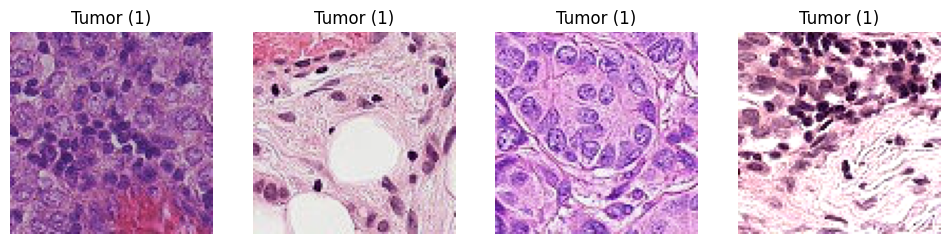

In [ ]:
# ==========================================
# CELL 2.5: DATASET EXPLORATION
# ==========================================
import matplotlib.pyplot as plt
import numpy as np

print("Fetching a single batch of data...")
# Pull one batch from the training loader
images, labels = next(iter(train_loader))

# 1. Analyze the Dimensions
print("\n--- TENSOR SHAPES ---")
print(f"Images Tensor: {images.shape}")
print(f"Labels Tensor: {labels.shape}")

# 2. Analyze the Labels
print("\n--- LABEL INFORMATION ---")
unique_labels = torch.unique(labels)
print(f"Unique Labels in this batch: {unique_labels.tolist()}")
print(f"Number of 'Normal' (0) samples: {(labels == 0).sum().item()}")
print(f"Number of 'Tumor' (1) samples: {(labels == 1).sum().item()}")

# 3. Visualize the Data (Un-normalize to see real colors)
print("\n--- VISUALIZING TISSUE SAMPLES ---")
def imshow(inp, title=None):
    """Imshow for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    # Undo the exact PCam normalization we applied in Cell 2
    mean = np.array([0.701, 0.538, 0.692])
    std = np.array([0.235, 0.277, 0.213])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1) # Clip values to stay within [0, 1] for matplotlib
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.axis('off')

# Plot the first 4 images in the batch
fig = plt.figure(figsize=(12, 4))
for i in range(4):
    ax = fig.add_subplot(1, 4, i+1)
    label_name = "Tumor (1)" if labels[i].item() == 1 else "Normal (0)"
    imshow(images[i], title=label_name)
plt.show()

In [ ]:
# ==========================================
# CELL 3: PURE PYTORCH - THE LIFTING LAYER
# ==========================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class LiftingConv2d(nn.Module):
    """
    Lifts standard 2D images (Z^2) onto the D4 Group Manifold (G).
    """
    def __init__(self, in_channels, out_features, kernel_size=3, padding=1):
        super().__init__()
        self.in_channels = in_channels
        self.out_features = out_features # How many distinct geometric patterns to learn
        self.kernel_size = kernel_size
        self.padding = padding

        # 1. Define the raw, learnable weights
        # Shape: [out_features, in_channels, K, K]
        # We wrap it in nn.Parameter so PyTorch knows to calculate gradients for it.
        self.weight = nn.Parameter(
            torch.empty(out_features, in_channels, kernel_size, kernel_size)
        )

        # 2. Proper Kaiming Initialization
        # (We use this instead of purely random noise to prevent vanishing gradients)
        nn.init.kaiming_normal_(self.weight, mode='fan_out', nonlinearity='relu')

        # 3. Define the Bias
        # An equivariant bias must be identical across all 8 orientations of a single feature.
        self.bias = nn.Parameter(torch.zeros(out_features))

    def forward(self, x):
        # x is the input image tensor. Shape: [Batch, 3, H, W]

        # ---------------------------------------------------------
        # PHASE 1: MATHEMATICALLY GENERATE THE 8 D4 FILTERS
        # ---------------------------------------------------------
        w_0 = self.weight

        # Rotations (Counter-clockwise using PyTorch's rot90)
        # dims=[2, 3] ensures we only rotate the spatial Height/Width dimensions
        w_90  = torch.rot90(w_0, k=1, dims=[2, 3])
        w_180 = torch.rot90(w_0, k=2, dims=[2, 3])
        w_270 = torch.rot90(w_0, k=3, dims=[2, 3])

        # Reflections (Horizontal flip along the Width dimension, dim=3)
        w_f0   = torch.flip(w_0, dims=[3])
        w_f90  = torch.flip(w_90, dims=[3])
        w_f180 = torch.flip(w_180, dims=[3])
        w_f270 = torch.flip(w_270, dims=[3])

        # ---------------------------------------------------------
        # PHASE 2: STACKING THE MATRIX
        # ---------------------------------------------------------
        # Stack the 8 variations. Shape becomes: [8, out_features, in_channels, K, K]
        stacked_weights = torch.stack([w_0, w_90, w_180, w_270, w_f0, w_f90, w_f180, w_f270], dim=0)

        # We need the output channels grouped by feature, not by rotation angle.
        # Transpose swaps the first two dimensions: [out_features, 8, in_channels, K, K]
        transposed_weights = stacked_weights.transpose(0, 1)

        # Flatten the feature and orientation dimensions so PyTorch's conv2d can read it.
        # Final shape: [out_features * 8, in_channels, K, K]
        expanded_weights = transposed_weights.reshape(
            self.out_features * 8, self.in_channels, self.kernel_size, self.kernel_size
        )

        # Expand the bias to match the 8 orientations
        # Shape: [out_features * 8]
        expanded_bias = self.bias.repeat_interleave(8)

        # ---------------------------------------------------------
        # PHASE 3: THE FUNCTIONAL CONVOLUTION
        # ---------------------------------------------------------
        # Hand the massive generated weight matrix to the C++ backend for the sliding window
        out = F.conv2d(x, expanded_weights, bias=expanded_bias, padding=self.padding)

        return out

print("Custom PyTorch Lifting Layer Compiled.")

Custom PyTorch Lifting Layer Compiled.


In [ ]:
# ==========================================
# CELL 4: PURE PYTORCH - GROUP CONVOLUTION (G -> G)
# ==========================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class GroupConv2d(nn.Module):
    """
    Transforms features strictly on the D4 Group Manifold (G -> G).
    Input has 8 orientations per feature. Output has 8 orientations per feature.
    """
    def __init__(self, in_features, out_features, kernel_size=3, padding=1, stride=1):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.kernel_size = kernel_size
        self.padding = padding
        self.stride = stride # We need this to implement the "spatial squeeze" later

        # 1. The 5-Dimensional Weight Tensor
        # Shape: [out_features, in_features, 8_orientations, K, K]
        self.weight = nn.Parameter(
            torch.empty(out_features, in_features, 8, kernel_size, kernel_size)
        )
        nn.init.kaiming_normal_(self.weight, mode='fan_out', nonlinearity='relu')
        self.bias = nn.Parameter(torch.zeros(out_features))

        # 2. Hard-coding the D4 Physics (The Permutation Maps)
        # register_buffer tells PyTorch: "Move these to the GPU, but DO NOT try to learn/update them."
        self.register_buffer('rot_90_idx', torch.tensor([3, 0, 1, 2, 7, 4, 5, 6]))
        self.register_buffer('rot_180_idx', torch.tensor([2, 3, 0, 1, 6, 7, 4, 5]))
        self.register_buffer('rot_270_idx', torch.tensor([1, 2, 3, 0, 5, 6, 7, 4]))

        self.register_buffer('flip_0_idx', torch.tensor([4, 5, 6, 7, 0, 1, 2, 3]))
        self.register_buffer('flip_90_idx', torch.tensor([7, 4, 5, 6, 3, 0, 1, 2]))
        self.register_buffer('flip_180_idx', torch.tensor([6, 7, 4, 5, 2, 3, 0, 1]))
        self.register_buffer('flip_270_idx', torch.tensor([5, 6, 7, 4, 1, 2, 3, 0]))

    def forward(self, x):
        # x shape: [Batch, in_features * 8, Height, Width]
        w_0 = self.weight # Base filter: [out, in, 8, K, K]

        # ---------------------------------------------------------
        # PHASE 1: GENERATE THE 8 TRANSFORMED FILTERS
        # ---------------------------------------------------------
        # Step A: Rotate the spatial grid (dims 3 and 4)
        # Step B: Permute the orientation depth channels using our index buffers (dim 2)

        w_90  = torch.rot90(w_0, k=1, dims=[3, 4])[:, :, self.rot_90_idx, :, :]
        w_180 = torch.rot90(w_0, k=2, dims=[3, 4])[:, :, self.rot_180_idx, :, :]
        w_270 = torch.rot90(w_0, k=3, dims=[3, 4])[:, :, self.rot_270_idx, :, :]

        # For reflections, we flip the spatial grid horizontally, THEN permute the depth channels.
        w_f0   = torch.flip(w_0, dims=[4])[:, :, self.flip_0_idx, :, :]
        w_f90  = torch.flip(torch.rot90(w_0, k=1, dims=[3, 4]), dims=[4])[:, :, self.flip_90_idx, :, :]
        w_f180 = torch.flip(torch.rot90(w_0, k=2, dims=[3, 4]), dims=[4])[:, :, self.flip_180_idx, :, :]
        w_f270 = torch.flip(torch.rot90(w_0, k=3, dims=[3, 4]), dims=[4])[:, :, self.flip_270_idx, :, :]

        # ---------------------------------------------------------
        # PHASE 2: STACK AND RESHAPE FOR PYTORCH
        # ---------------------------------------------------------
        # Stack into 6D tensor: [8_out_angles, out_feat, in_feat, 8_in_angles, K, K]
        stacked = torch.stack([w_0, w_90, w_180, w_270, w_f0, w_f90, w_f180, w_f270], dim=0)

        # Swap so output features are the very first dimension
        transposed = stacked.transpose(0, 1)

        # Crush down to standard 4D PyTorch format: [out_feat * 8, in_feat * 8, K, K]
        expanded_weights = transposed.reshape(
            self.out_features * 8, self.in_features * 8, self.kernel_size, self.kernel_size
        )
        expanded_bias = self.bias.repeat_interleave(8)

        # ---------------------------------------------------------
        # PHASE 3: THE FUNCTIONAL CONVOLUTION
        # ---------------------------------------------------------
        out = F.conv2d(x, expanded_weights, bias=expanded_bias, padding=self.padding, stride=self.stride)

        return out

print("Custom PyTorch G -> G Layer Compiled.")

Custom PyTorch G -> G Layer Compiled.


In [ ]:
# ==========================================
# CELL 5: DEEP CUSTOM PURE PYTORCH G-CNN
# ==========================================
import torch
import torch.nn as nn
import torch.nn.functional as F

class GroupBatchNorm(nn.Module):
    """
    Standard BatchNorm2d expects [Batch, Channels, Height, Width].
    However, our G-CNN outputs [Batch, Features * 8, Height, Width].
    To normalize properly across all 8 group states (rotations/reflections) simultaneously,
    we must trick PyTorch into treating the group dimension as a "Depth" dimension.
    """
    def __init__(self, features):
        super().__init__()
        self.features = features
        # We use 3D Batch Norm because our data is technically 3D: (Height, Width, Group)
        self.bn = nn.BatchNorm3d(features)

    def forward(self, x):
        b, _, h, w = x.shape
        # Step 1: Unpack the channels.
        # Changes shape from [B, Features * 8, H, W] -> [B, Features, 8, H, W]
        x_reshaped = x.view(b, self.features, 8, h, w)

        # Step 2: Apply 3D Batch Normalization.
        out = self.bn(x_reshaped)

        # Step 3: Repack the channels so standard 2D operations (like pooling) don't break.
        # Changes shape back to [B, Features * 8, H, W]
        return out.view(b, self.features * 8, h, w)

class GroupPooling(nn.Module):
    """
    This is the exact moment the network shifts from Equivariant (tracking rotations)
    to Invariant (ignoring rotations to make a final diagnosis).
    """
    def __init__(self, features):
        super().__init__()
        self.features = features

    def forward(self, x):
        b, _, h, w = x.shape
        # Step 1: Unpack the channels to expose the 8 D_4 group elements.
        # Shape: [B, Features, 8, H, W]
        x_reshaped = x.view(b, self.features, 8, h, w)

        # Step 2: Max Pooling across the Group Dimension (dim=2).
        # We look at all 8 rotated states and keep the maximum activation.
        # If the network sees a tumor at 90 degrees but not 0 degrees, it keeps the 90-degree signal.
        # Shape collapses from [B, Features, 8, H, W] -> [B, Features, H, W]
        out, _ = torch.max(x_reshaped, dim=2)
        return out

class DeepCustomGCNN(nn.Module):
    def __init__(self, n_classes=2):
        super().__init__()

        # Phase 1: Lifting Layer (Z^2 -> D_4)
        # Takes a standard 3-channel RGB image and explicitly maps it into the 8 group states.
        # Output channels = 24 features * 8 states = 192 actual channels.
        self.lift = LiftingConv2d(in_channels=3, out_features=24, kernel_size=3, padding=1)
        self.bn1 = GroupBatchNorm(24)

        # Phase 2: Group Convolutions (D_4 -> D_4)
        # These layers permute their kernels internally to track the 8 orientations.
        self.gconv1 = GroupConv2d(in_features=24, out_features=24, kernel_size=3, padding=1)
        self.bn2 = GroupBatchNorm(24)
        self.pool1 = nn.MaxPool2d(2, 2) # Spatial pooling (reduces H and W by half)

        self.gconv2 = GroupConv2d(in_features=24, out_features=48, kernel_size=3, padding=1)
        self.bn3 = GroupBatchNorm(48)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.gconv3 = GroupConv2d(in_features=48, out_features=48, kernel_size=3, padding=1)
        self.bn4 = GroupBatchNorm(48)
        self.pool3 = nn.MaxPool2d(2, 2)

        # Final feature extraction layer.
        # Output channels = 96 features * 8 states = 768 actual channels.
        self.gconv4 = GroupConv2d(in_features=48, out_features=96, kernel_size=3, padding=1)
        self.bn5 = GroupBatchNorm(96)

        # Phase 3: Invariance & Classification (D_4 -> Z^2 -> Binary)
        self.gpool = GroupPooling(features=96)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1)) # Forces spatial dimensions to 1x1
        self.fc = nn.Linear(96, n_classes)

    def forward(self, x):
        # Input 'x' shape: [B, 3, 96, 96] (Standard PCam Patch)

        # 1. Lift the image into the D_4 manifold.
        # Shape becomes: [B, 192, 96, 96]
        x = F.relu(self.bn1(self.lift(x)))

        # 2. Extract features while maintaining equivariance.
        # The MaxPools reduce spatial resolution, but the 8 group states remain intact.
        x = self.pool1(F.relu(self.bn2(self.gconv1(x)))) # Shape: [B, 192, 48, 48]
        x = self.pool2(F.relu(self.bn3(self.gconv2(x)))) # Shape: [B, 384, 24, 24]
        x = self.pool3(F.relu(self.bn4(self.gconv3(x)))) # Shape: [B, 384, 12, 12]
        x = F.relu(self.bn5(self.gconv4(x)))             # Shape: [B, 768, 12, 12]

        # 3. Collapse the group dimension to lock in rotational invariance.
        # Shape drastically reduces from 768 channels down to 96 base features.
        x = self.gpool(x)                                # Shape: [B, 96, 12, 12]

        # 4. Collapse the spatial dimensions for the final linear layer.
        x = self.adaptive_pool(x)                        # Shape: [B, 96, 1, 1]
        x = x.view(x.size(0), -1)                        # Shape: [B, 96]

        # 5. Output the final binary prediction (Cancer vs. Healthy).
        x = self.fc(x)                                   # Shape: [B, 2]
        return x

model = DeepCustomGCNN().to(device)
print("Deep 5-Layer Pure PyTorch G-CNN Assembled!")

Deep 5-Layer Pure PyTorch G-CNN Assembled!


In [ ]:
# ==========================================
# CELL 6: TRAINING & EVALUATION (FULL RUN)
# ==========================================
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import accuracy_score, roc_auc_score
from tqdm import tqdm
import numpy as np

# 1. The Full Training Loop
def train_model(model, loader, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    # Thermostat: Check every 1000 batches. Drop LR by half if stuck for 2 checks.
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        current_lr = optimizer.param_groups[0]['lr']

        loop = tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}")
        for batch_idx, (images, labels) in enumerate(loop):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            avg_loss = running_loss / (batch_idx + 1)

            loop.set_postfix(avg_loss=f"{avg_loss:.4f}", lr=f"{current_lr:.6f}")

            # Every 1000 batches, check the thermostat
            if batch_idx > 0 and batch_idx % 1000 == 0:
                old_lr = current_lr
                scheduler.step(avg_loss)
                current_lr = optimizer.param_groups[0]['lr']

                if current_lr < old_lr:
                    print(f"\n[THERMOSTAT] Plateau detected at epoch {epoch+1}, batch {batch_idx}! Dropping LR to {current_lr}")

    return model

# 2. The Robustness Evaluation Loop
def evaluate_robustness(model, test_loaders):
    model.eval()
    results = {}
    base_predictions = None

    with torch.no_grad():
        for angle_name, loader in test_loaders.items():
            all_preds, all_labels, all_probs = [], [], []

            loop = tqdm(loader, desc=f"Testing {angle_name}")
            for images, labels in loop:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                probs = torch.softmax(outputs, dim=1)[:, 1]
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            acc = accuracy_score(all_labels, all_preds)
            auc = roc_auc_score(all_labels, all_probs)

            if angle_name == "0_deg":
                base_predictions = np.array(all_preds)
                flip_rate = 0.0
            else:
                current_predictions = np.array(all_preds)
                flips = np.sum(current_predictions != base_predictions)
                flip_rate = (flips / len(base_predictions)) * 100

            results[angle_name] = {"Accuracy": acc, "AUC": auc, "Flip_Rate_%": flip_rate}

    return results

# 3. Print Formatting
def print_results(model_name, results):
    print(f"\n{'='*55}")
    print(f"RESULTS FOR {model_name.upper()}")
    print(f"{'='*55}")
    print(f"{'Angle':<10} | {'Accuracy':<10} | {'AUC':<10} | {'Flip Rate':<10}")
    print("-" * 55)
    for angle, metrics in results.items():
        print(f"{angle:<10} | {metrics['Accuracy']:.4f}   | {metrics['AUC']:.4f}   | {metrics['Flip_Rate_%']:.2f}%")

# ==========================================
# 4. EXECUTE THE FULL EXPERIMENT
# ==========================================
print("\n>>> STARTING FULL DEEP D4 CNN TRAINING RUN <<<")
# Pass the EPOCHS variable we defined in Cell 1
trained_gcnn = train_model(model, train_loader, epochs=EPOCHS)
gcnn_results = evaluate_robustness(trained_gcnn, test_loaders)
print_results("Deep Custom D4 CNN (5 Epochs)", gcnn_results)


>>> STARTING FULL DEEP D4 CNN TRAINING RUN <<<


Epoch 5/5:  49%|████▉     | 4001/8192 [21:10<22:07,  3.16it/s, avg_loss=0.1262, lr=0.001000]


[THERMOSTAT] Plateau detected at epoch 5, batch 4000! Dropping LR to 0.0005


Testing 270_deg: 100%|██████████| 1024/1024 [02:02<00:00,  8.38it/s]


RESULTS FOR DEEP CUSTOM D4 CNN (5 EPOCHS)
Angle      | Accuracy   | AUC        | Flip Rate 
-------------------------------------------------------
0_deg      | 0.8362   | 0.9439   | 0.00%
90_deg     | 0.8229   | 0.9393   | 4.81%
180_deg    | 0.8362   | 0.9439   | 0.00%
270_deg    | 0.8229   | 0.9393   | 4.81%


In [ ]:
# ==========================================
# CELL 7: SAVE MODEL WEIGHTS TO GOOGLE DRIVE
# ==========================================
import os
from datetime import datetime
import torch

# 1. Define the permanent save path on your Google Drive
# We will put this right next to your PCAM_Data folder
drive_model_dir = '/content/drive/MyDrive/Erdos_Project/Models'
os.makedirs(drive_model_dir, exist_ok=True)

# 2. Create a unique filename with today's date and time
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
model_filename = f"GCNN_D4_PCAM_5Epochs_{timestamp}.pth"
save_path = os.path.join(drive_model_dir, model_filename)

# 3. Save the model's "state_dict" (the actual learned weights and biases)
print(f"Saving model weights to: {save_path} ...")
torch.save(model.state_dict(), save_path)

print("\n✅ Model successfully saved to Google Drive!")
print("Your trained network is now permanently secure.")

Saving model weights to: /content/drive/MyDrive/Erdos_Project/Models/GCNN_D4_PCAM_5Epochs_20260307_0204.pth ...

✅ Model successfully saved to Google Drive!
Your trained network is now permanently secure.


In [ ]:
# ==========================================
# CELL 7.5: LOAD SAVED WEIGHTS FROM DRIVE
# ==========================================
import os
import torch

# 1. Define the exact path to your saved model
drive_model_dir = '/content/drive/MyDrive/Erdos_Project/Models'
model_filename = "GCNN_D4_PCAM_5Epochs_20260307_0204.pth"
load_path = os.path.join(drive_model_dir, model_filename)

print(f"Loading weights from: {load_path} ...")

# 2. Inject the weights into the empty model skeleton
model.load_state_dict(torch.load(load_path, map_location=device))

# 3. Lock the model into evaluation mode
model.to(device)
model.eval()

print("Brain successfully transplanted! The model is fully restored.")

Loading weights from: /content/drive/MyDrive/Erdos_Project/Models/GCNN_D4_PCAM_5Epochs_20260307_0204.pth ...
Brain successfully transplanted! The model is fully restored.


In [ ]:
# ==========================================
# CELL 8: CLINICAL THRESHOLD RECALL
# ==========================================
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import recall_score, confusion_matrix

all_labels = []
all_probs = []

print("Running Evaluation with Clinical Threshold...")

with torch.no_grad():
    for images, labels in test_loaders["0_deg"]:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)

        # EXTRACT RAW PROBABILITIES instead of hard predictions
        # Softmax converts raw logits into percentages (0.0 to 1.0)
        probs = F.softmax(outputs, dim=1)

        # Grab the probability specifically for Class 1 (Cancer)
        cancer_probs = probs[:, 1]

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(cancer_probs.cpu().numpy())

# Convert to numpy arrays
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# ==========================================
# SET CLINICAL THRESHOLD (e.g., 0.25 instead of default 0.50)
# ==========================================
clinical_threshold = 0.25

# If probability > 25%, flag as cancer (1). Otherwise healthy (0).
custom_preds = (all_probs >= clinical_threshold).astype(int)

# Calculate new metrics
recall = recall_score(all_labels, custom_preds)
tn, fp, fn, tp = confusion_matrix(all_labels, custom_preds).ravel()

print("\n=======================================================")
print(f"      CLINICAL METRICS (THRESHOLD = {clinical_threshold*100}%)")
print("=======================================================")
print(f"Recall (Sensitivity):            {recall:.4f} ({(recall*100):.2f}%)")
print("-------------------------------------------------------")
print(f"True Positives (Cancer Found):   {tp}")
print(f"False Negatives (Cancer Missed): {fn}  ")
print("-------------------------------------------------------")
print(f"True Negatives (Healthy Found):  {tn}")
print(f"False Positives (False Alarms):  {fp} ")
print("=======================================================")

Running Evaluation with Clinical Threshold...

      CLINICAL METRICS (THRESHOLD = 25.0%)
Recall (Sensitivity):            0.7689 (76.89%)
-------------------------------------------------------
True Positives (Cancer Found):   12593
False Negatives (Cancer Missed): 3784  
-------------------------------------------------------
True Negatives (Healthy Found):  15853
False Positives (False Alarms):  538 


In [ ]:
from sklearn.metrics import precision_recall_curve

# Calculate precision and recall for all possible thresholds
precisions, recalls, thresholds = precision_recall_curve(all_labels, all_probs)

# Find the exact threshold where Recall crosses 95% (0.95)
target_recall = 0.95
idx = np.where(recalls >= target_recall)[0][-1]
optimal_threshold = thresholds[idx]

print(f"To achieve {target_recall*100}% Recall, your clinical threshold must be set to: {optimal_threshold:.4f} ({(optimal_threshold*100):.2f}%)")

To achieve 95.0% Recall, your clinical threshold must be set to: 0.0155 (1.55%)


In [ ]:
# ==========================================
# STANDALONE EVALUATION CELL (AUC & FLIP RATE)
# ==========================================
import torch
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score
from tqdm import tqdm

def evaluate_robustness(eval_model, loaders):
    # Lock model to evaluation mode
    eval_model.eval()
    results = {}
    base_predictions = None

    with torch.no_grad():
        for angle_name, loader in loaders.items():
            all_preds, all_labels, all_probs = [], [], []

            loop = tqdm(loader, desc=f"Testing {angle_name}")
            for images, labels in loop:
                images, labels = images.to(device), labels.to(device)

                # Forward pass
                outputs = eval_model(images)

                # Extract probabilities and hard predictions
                probs = torch.softmax(outputs, dim=1)[:, 1]
                _, preds = torch.max(outputs, 1)

                all_preds.extend(preds.cpu().numpy())
                all_probs.extend(probs.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())

            # Calculate metrics
            acc = accuracy_score(all_labels, all_preds)
            auc = roc_auc_score(all_labels, all_probs)

            # Calculate flip rate against the 0-degree baseline
            if angle_name == "0_deg":
                base_predictions = np.array(all_preds)
                flip_rate = 0.0
            else:
                current_predictions = np.array(all_preds)
                flips = np.sum(current_predictions != base_predictions)
                flip_rate = (flips / len(base_predictions)) * 100

            results[angle_name] = {"Accuracy": acc, "AUC": auc, "Flip_Rate_%": flip_rate}

    return results

# ==========================================
# EXECUTE EVALUATION ON LOADED MODEL
# ==========================================
print("\n>>> STARTING ROBUSTNESS EVALUATION <<<")
# Uses the 'model' and 'test_loaders' already residing in memory
final_results = evaluate_robustness(model, test_loaders)

# Print formatting (Updated spacing for '_flip' strings)
print(f"\n{'='*60}")
print(f"RESULTS FOR FULLY TRAINED CUSTOM MODEL (FULL D4 MANIFOLD)")
print(f"{'='*60}")
print(f"{'Angle':<15} | {'Accuracy':<10} | {'AUC':<10} | {'Flip Rate':<10}")
print("-" * 60)
for angle, metrics in final_results.items():
    print(f"{angle:<15} | {metrics['Accuracy']:.4f}   | {metrics['AUC']:.4f}   | {metrics['Flip_Rate_%']:.2f}%")


>>> STARTING ROBUSTNESS EVALUATION <<<


Testing 270_deg_flip: 100%|██████████| 1024/1024 [00:32<00:00, 31.11it/s]


RESULTS FOR FULLY TRAINED CUSTOM MODEL (FULL D4 MANIFOLD)
Angle           | Accuracy   | AUC        | Flip Rate 
------------------------------------------------------------
0_deg           | 0.8362   | 0.9439   | 0.00%
0_deg_flip      | 0.8362   | 0.9439   | 0.00%
90_deg          | 0.8229   | 0.9393   | 4.82%
90_deg_flip     | 0.8229   | 0.9393   | 4.82%
180_deg         | 0.8362   | 0.9439   | 0.00%
180_deg_flip    | 0.8362   | 0.9439   | 0.00%
270_deg         | 0.8229   | 0.9393   | 4.82%
270_deg_flip    | 0.8229   | 0.9393   | 4.82%


In [ ]:
# ==========================================
# CELL: G-CNN CLINICAL THRESHOLD RECALL (FULL D4)
# ==========================================
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import recall_score, confusion_matrix
from tqdm import tqdm

clinical_threshold = 0.25

print(f"\n{'='*70}")
print(f"   G-CNN CLINICAL METRICS (THRESHOLD = {clinical_threshold*100}%)")
print(f"{'='*70}")
# Increased spacing from <10 to <15 to fit the reflection names
print(f"{'State':<15} | {'Recall':<10} | {'Missed (FN)':<12} | {'False Alarms (FP)'}")
print("-" * 70)

# Ensure the model is in evaluation mode
model.eval()

with torch.no_grad():
    # Loop through all 8 states: 4 rotations + 4 reflections
    for state_name, loader in test_loaders.items():
        labels_list = []
        probs_list = []

        # Process the specific dataloader
        loop = tqdm(loader, desc=f"Auditing {state_name}", leave=False)
        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            # Forward pass through the discrete G-CNN
            outputs = model(images)

            # Extract raw probabilities for Class 1 (Cancer) using Softmax
            probs = F.softmax(outputs, dim=1)[:, 1]

            labels_list.extend(labels.cpu().numpy())
            probs_list.extend(probs.cpu().numpy())

        # Convert to numpy arrays
        angle_labels = np.array(labels_list)
        angle_probs = np.array(probs_list)

        # Apply the custom 25% Clinical Threshold
        custom_preds = (angle_probs >= clinical_threshold).astype(int)

        # Calculate metrics
        recall = recall_score(angle_labels, custom_preds)
        tn, fp, fn, tp = confusion_matrix(angle_labels, custom_preds).ravel()

        # Print results row for the current manifold state
        print(f"{state_name:<15} | {recall:.4f}     | {fn:<12} | {fp}")

print("=" * 70)


   G-CNN CLINICAL METRICS (THRESHOLD = 25.0%)
State           | Recall     | Missed (FN)  | False Alarms (FP)
----------------------------------------------------------------------


0_deg           | 0.7689     | 3784         | 538


0_deg_flip      | 0.7689     | 3784         | 538


90_deg          | 0.7502     | 4091         | 603


90_deg_flip     | 0.7502     | 4091         | 603


180_deg         | 0.7689     | 3784         | 538


180_deg_flip    | 0.7689     | 3784         | 538


270_deg         | 0.7502     | 4091         | 603


270_deg_flip    | 0.7502     | 4091         | 603
